# Анализ лояльности пользователей Яндекс Афиш

## Цели и задачи проекта:
С помощью датасета с информацией о клиентах и их активности, надо проанализировать и выявить портрет пользователя, который с большей вероятностью будет возвращаться на платформу и делать повторные заказы. Это поможет оптимизировать рекламные бюжеты и влиять на продолжительность удержания клиента

## Данные:
Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- user_id — уникальный идентификатор пользователя, совершившего заказ;
- device_type_canonical — тип устройства, с которого был оформлен заказ (mobile — мобильные устройства, desktop — стационарные);
- order_id — уникальный идентификатор заказа;
- order_dt — дата создания заказа (используйте данные created_dt_msk);
- order_ts — дата и время создания заказа (используйте данные created_ts_msk);
- currency_code — валюта оплаты;
- revenue — выручка от заказа;
- tickets_count — количество купленных билетов;
- days_since_prev — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- event_id — уникальный идентификатор мероприятия;
- service_name — название билетного оператора;
- event_type_main — основной тип мероприятия (театральная постановка, концерт и так далее);
- region_name — название региона, в котором прошло мероприятие;
- city_name — название города, в котором прошло мероприятие.


### 1. Загрузка данных и сбор общей информации

In [1]:
#Установка необходимых библиотек
!pip install phik


In [2]:
!pip install sqlalchemy

In [3]:
!pip install psycopg2

In [4]:
#Импорт необходимых библиотек для анализа данных
import pandas as pd
import numpy as np

#Импорт библиотек для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

#Импорт внутрненних библиотек для работы с чувствительными файлами
import os
import dotenv
from sqlalchemy import create_engine

In [5]:
#Подгружаю данные с доступом к БД через .env-файл
db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PASSWORD'), # пароль
    'host': os.getenv('DB_HOST'),
    'port': os.getenv('DB_PORT'), # порт подключения
    'db': os.getenv('DB_NAME')
}

In [6]:
#Импортирую строку для подключения
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
) 

In [7]:
#Создаем соединение с БД
engine = create_engine(connection_string) 

In [8]:
#Проверяю подключение к БД
db_config

{'user': 'praktikum_student',
 'pwd': 'Sdf4$2;d-d30pp',
 'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
 'port': '6432',
 'db': 'data-analyst-afisha'}

In [9]:
#Выгружаем данные из БД с помощью SQL-запроса
query = '''
-- Настройка параметра synchronize_seqscans важна для проверки
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
)
-- Напишите ваш запрос ниже
SELECT p.user_id,
      p.device_type_canonical,
      p.order_id,
      p.created_dt_msk AS order_dt,
      p.created_ts_msk AS order_ts,
      p.currency_code,
      p.revenue,
      p.tickets_count,
      EXTRACT (DAY FROM (p.created_dt_msk - LAG(p.created_dt_msk) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk)))::INTEGER AS days_since_prev,
      p.event_id,
      e.event_name_code AS event_name,
      e.event_type_main,
      p.service_name,
      r.region_name,
      c.city_name
FROM afisha.purchases p
JOIN afisha.events e USING(event_id)
JOIN afisha.city c USING(city_id)
JOIN afisha.regions r USING(region_id)
WHERE p.device_type_canonical IN ('mobile', 'desktop') AND e.event_type_main NOT IN ('фильм')
ORDER BY p.user_id;
'''

In [10]:
#Присваиваем то что извлекаем из БД переменной
df = pd.read_sql_query(query, con=engine)

In [11]:
#Проверяю результат выгрузки из БД
df.head(3)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск


In [12]:
#Проверяю размер датасета
shape = df.shape[0]
shape

290611

In [13]:
#Проверяю выгрузку колонок
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

##### Промежуточный вывод по шагу 1 (Загрузка и сбор общей информации о датасте):

- 1. Данные выгрузились корректно
- 2. На первый взгляд данные соответствуют своим типам в колонках
- 3. Вижу явно пропущенные значения только в колонке "days_since_prev"
- 4. Названия колонок приведены к одному типу
- 5. Размерность колонок с целочисленными показателями можно уменьшить

### 2. Предобработка данных

Задача 2.1. Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

In [14]:
#Подгружаю датасет с информацией о курсе валют в переменную
df_kzt = pd.read_csv('final_tickets_tenge_df.csv')

In [15]:
#Проверяю результат выгрузки
df_kzt.head(3)

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt


In [16]:
#Смотрю на типы колонок 
df_kzt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Идея простая, соединим 2 датасета с помощью left-join (Левая таблица - df, правая df_kzt)

In [17]:
#Преобразовываю тип data, чтобы правильно соединить таблицы
df_kzt['data'] = pd.to_datetime(df_kzt['data'])



In [18]:
#Проверяю результат преобразования типов
df_kzt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     357 non-null    datetime64[ns]
 1   nominal  357 non-null    int64         
 2   curs     357 non-null    float64       
 3   cdx      357 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 11.3+ KB


In [19]:
#Соединяю таблицы
df = df.merge(df_kzt[['data', 'curs']], left_on='order_dt', right_on='data', how='left').drop('data', axis=1)

In [20]:
#Проверяю результат
df.head(5)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,curs
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,18.6972
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,18.3419
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,19.6475
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,18.5010
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,19.6648


In [21]:
#Теперь делаем перерасчет выручки только для тех колонок, где валюта казахский тенге
df['revenue_rub'] = df['revenue'].where(df['currency_code'] == 'rub', df['revenue'] * df['curs'] / 100)

In [22]:
#Проверяю результат
df[df['currency_code'] == 'kzt']

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,curs,revenue_rub
70,0033403583a55ed,mobile,7850214,2024-09-17,2024-09-17 16:52:06,kzt,518.10,4,20.0,559919,f5ec2467-ee48-42f3-89a0-a2d90d1d6fce,другое,Билеты без проблем,Верхоречная область,Серебрянка,19.0125,98.503762
89,0040e12d70fae81,desktop,8634925,2024-09-02,2024-09-02 19:49:14,kzt,347.18,3,39.0,559476,61ec7c0e-ea0c-4a3e-a63a-09cbe1bc6177,другое,Билеты без проблем,Верхоречная область,Серебрянка,18.9330,65.731589
96,0054b38b2653e6e,mobile,7625522,2024-09-09,2024-09-09 18:06:04,kzt,328.77,4,NaN,559582,524f434e-0381-4f47-9688-7c4e41961b65,другое,Билеты без проблем,Верхоречная область,Серебрянка,18.5991,61.148261
277,00f4f5244501ce6,mobile,720419,2024-06-11,2024-06-11 20:15:57,kzt,22021.55,5,NaN,536826,76af4f88-c554-4e9e-9df4-1cc8aeec8959,концерты,Мой билет,Верхоречная область,Серебрянка,19.8928,4380.702898
460,01370a0e9c1a7d5,desktop,5227657,2024-06-04,2024-06-04 13:28:17,kzt,7397.66,4,1.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Мой билет,Шанырский регион,Широковка,19.9833,1478.296591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290484,ffc24188a1d58f2,mobile,6862648,2024-07-11,2024-07-11 12:39:48,kzt,4735.52,2,20.0,538828,603c97c6-b64f-4ec6-8de9-20b95c20b2b5,концерты,Билеты без проблем,Верхоречная область,Серебрянка,18.2738,865.359454
290485,ffc24188a1d58f2,mobile,6763294,2024-09-05,2024-09-05 12:07:00,kzt,4735.52,2,56.0,538828,603c97c6-b64f-4ec6-8de9-20b95c20b2b5,концерты,Билеты без проблем,Верхоречная область,Серебрянка,18.4217,872.363288
290486,ffc24188a1d58f2,mobile,3984021,2024-09-06,2024-09-06 19:20:03,kzt,1849.41,1,1.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Мой билет,Шанырский регион,Широковка,18.5504,343.072953
290488,ffc4133fbba20f4,mobile,8493898,2024-06-21,2024-06-21 13:41:39,kzt,3698.83,2,NaN,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Мой билет,Шанырский регион,Широковка,18.5791,687.209325


**Промежуточный итог по заданию 2.1:**
Была создана новая колонка c перерасчитанной выручкой из казахского тенге в рубли

##### Задача 2.2. Пропущенные значение и преобразование колонок

In [23]:
#Смотрю на количество пропусков в колонках
df.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
curs                         0
revenue_rub                  0
dtype: int64

In [24]:
#Изучим природу пропусков
df[df['days_since_prev'].isna()].head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,curs,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,18.6972,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,18.3419,289.45
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,18.5010,8.49
6,00096d1f542ab2b,desktop,6636941,2024-08-15,2024-08-15 16:48:48,rub,917.83,4,NaN,201953,2f98d69f-4e60-4ffc-8f16-e539383526b1,театр,Край билетов,Каменевский регион,Глиногорск,18.7730,917.83
7,000a55a418c128c,mobile,4657981,2024-09-29,2024-09-29 19:39:12,rub,47.78,1,NaN,265857,0d876e01-851e-458b-ba61-753e0e0c4063,театр,Лучшие билеты,Поленовский край,Дальнозолотск,19.3741,47.78


**Промежуточный итог по заданию 2.2:**
Было выявлено, что пропуски в колонке "days_since_prev" связаны с тем, что у клиентов просто нету повторных покупок, соответственно и временной разницы между покупками посчитать нельзя

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

In [26]:
#Создаю список колонок с целочисленными данными
columns=['order_id', 'tickets_count', 'event_id']

In [27]:
#Уменьшаем размерность с помощью цикла
for column in columns:
    df[column] = pd.to_numeric(df[column], downcast='integer')

In [28]:
#Проверяю результат
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

**Была уменьшена размерность колоноках с целочисленными данными**

In [29]:
#Смотрю названия и содержимое колонок
df.head(3)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,curs,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,18.6972,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,18.3419,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,19.6475,1258.57


In [30]:
#Проверка на дубликаты в категориальных колонках
#Создаем список категориальных колонок

columns=['device_type_canonical', 'currency_code', 'event_type_main', 'service_name']

In [31]:
for column in columns:
    print(f"Информация о колонке '{[column]}': ")
    print(f"Количество уникальных значений: {df[column].nunique()}")
    print(f"Количество дубликатов: {df[column].duplicated().sum()}")

Информация о колонке '['device_type_canonical']': 
Количество уникальных значений: 2
Количество дубликатов: 290609
Информация о колонке '['currency_code']': 
Количество уникальных значений: 2
Количество дубликатов: 290609
Информация о колонке '['event_type_main']': 
Количество уникальных значений: 7
Количество дубликатов: 290604
Информация о колонке '['service_name']': 
Количество уникальных значений: 36
Количество дубликатов: 290575


**Промежуточный итог по поиску дубликатов в категориальных колонках -**
Дубликатов не выявлено

**Распредление данных в колонках с целочисленными данныии**

In [32]:
#Смотрю содержимое колонок, чтобы выбрать числовые колонки
df.head(3)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,curs,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,18.6972,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,18.3419,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,19.6475,1258.57


По большому счету у нас есть только 2 колонки с целочисленными данными, которые нас интересуют - "tickets_count" и "revenue_rub"

In [33]:
#Смотрим на статистические показатели колонки tickets_count
df['tickets_count'].describe()

count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

**Промежуточные выводы:**
- Медиана не сильно отличается от среднего знач
- Есть аномальное максимальное значение

Есть смысл избавиться от выбросов

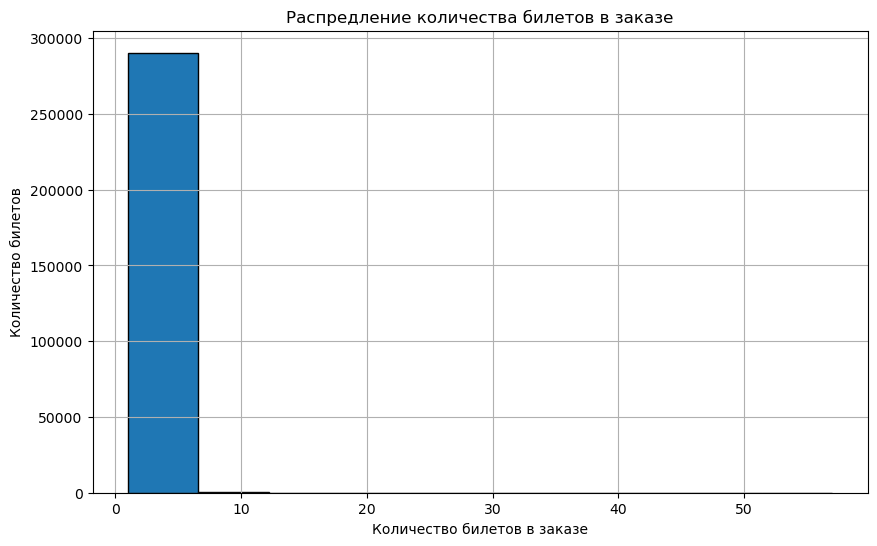

In [34]:
#Визуализация распределения значений в колонке "tickets_count"

plt.figure(figsize=(10,6))

plt.hist(df['tickets_count'], bins=10, edgecolor='black')
plt.title('Распредление количества билетов в заказе')
plt.xlabel('Количество билетов в заказе')
plt.ylabel('Количество билетов')

plt.grid(True)
plt.show()

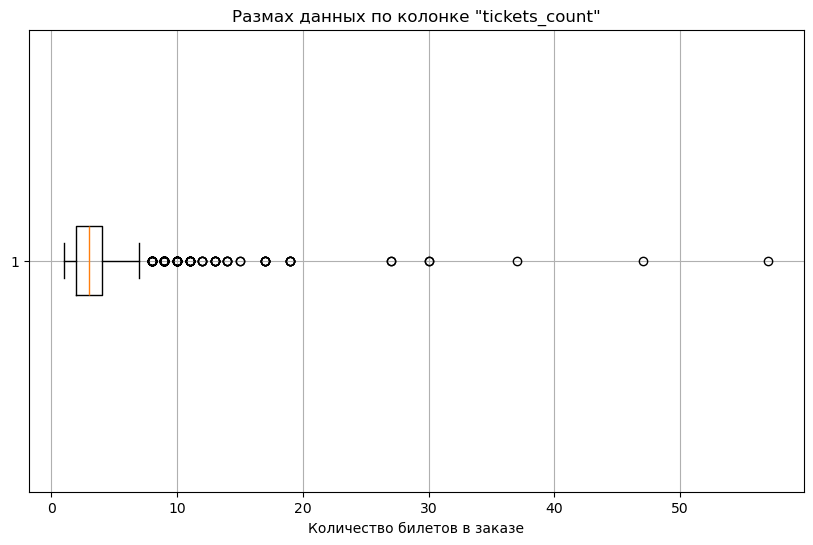

In [35]:
#Смотрим на диаграмму размаха (boxplot), для визуализации выбросов

plt.figure(figsize=(10,6))

plt.boxplot(df['tickets_count'], vert=False)
plt.title('Размах данных по колонке "tickets_count"')
plt.xlabel('Количество билетов в заказе')

plt.grid(True)
plt.show()

In [36]:
#Создадим вверхнюю границу данных
upper_limit_tickets = df['tickets_count'].quantile(0.99)

In [37]:
#Фильтруем данные по верхней границе
df = df[df['tickets_count'] < upper_limit_tickets]

In [38]:
#Проверяю статистические показания после фильтрации
df['tickets_count'].describe()

count    286140.000000
mean          2.700709
std           1.080536
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max           5.000000
Name: tickets_count, dtype: float64

**Промежуточный итог по колонке "tickets_count" - **
Мы избавились от аномально больших значений, теперь результаты аналитики будут более достоверными

In [39]:
#Смотрим статистические показатели колонки "revenue_rub"
df['revenue_rub'].describe()

count    286140.000000
mean        547.561074
std         869.882274
min         -90.760000
25%         111.920000
50%         346.060000
75%         793.960000
max       81174.540000
Name: revenue_rub, dtype: float64

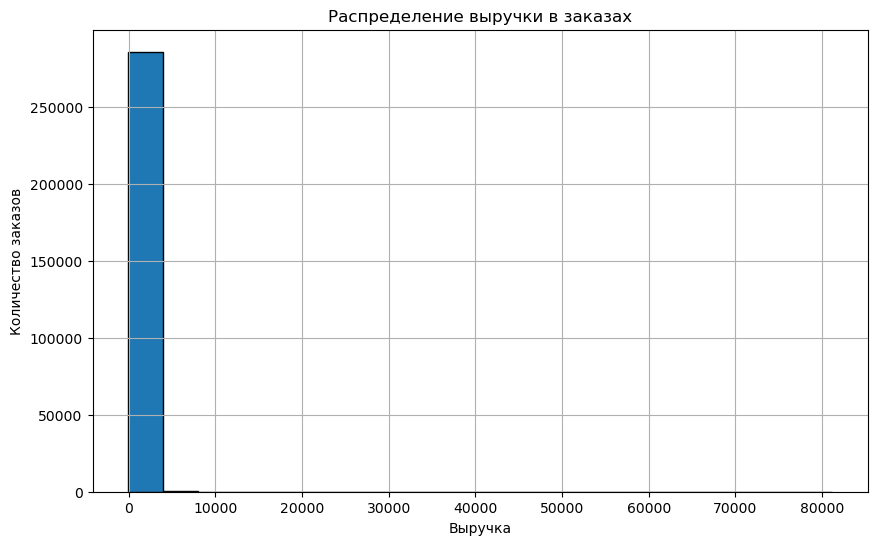

In [40]:
#Визуализирую распредление значений в колонке "revenue_rub"

plt.figure(figsize=(10,6))

plt.hist(df['revenue_rub'], bins=20, edgecolor='black')
plt.title('Распределение выручки в заказах')
plt.xlabel('Выручка')
plt.ylabel('Количество заказов')

plt.grid(True)
plt.show()

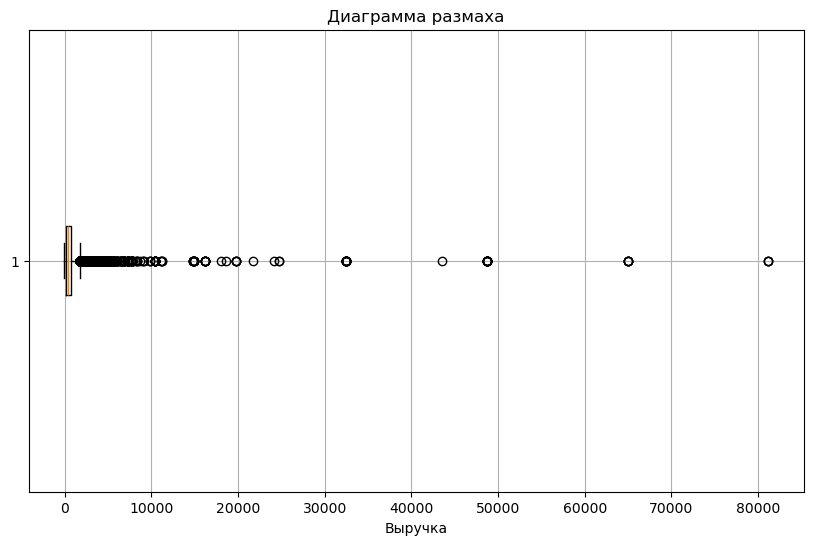

In [41]:
#Изучаю диаграмму размаха для анализа выбросов
plt.figure(figsize=(10,6))

plt.boxplot(df['revenue_rub'], vert=False)
plt.title('Диаграмма размаха')
plt.xlabel('Выручка')

plt.grid(True)
plt.show()

**Промежуточный вывод по колонке "revenue_rub":**
- Есть отрицательные значения
- Максимальное значение находится слишком далеко от среднего
- Среднее число отличается от медианы

Скорее всего есть выбросы

In [42]:
#Создаем верхнюю границу для "revenue_rub":
upper_limit_revenue = df['revenue_rub'].quantile(0.99)

In [43]:
#Фультруем колонку по верхней границе процентилей
df = df[df['revenue_rub'] < upper_limit_revenue]

In [44]:
#Проверяю стат показатели колонки после фильтрации
df['revenue_rub'].describe()

count    283185.000000
mean        509.484576
std         499.687321
min         -90.760000
25%         110.080000
50%         340.110000
75%         781.720000
max        2593.420000
Name: revenue_rub, dtype: float64

Уже намного лучше, теперь надо избавиться от отрицательных значений

In [45]:
#Фильтруем колонку с помощью маски
df = df[df['revenue_rub'] >= 0]

In [46]:
#Проверяем результат фильтрации
df['revenue_rub'].describe()

count    282805.000000
mean        510.172497
std         499.670110
min           0.000000
25%         110.890000
50%         340.690000
75%         782.080000
max        2593.420000
Name: revenue_rub, dtype: float64

In [47]:
#Считаем сколько строк мы отфильтровали
df.shape[0]

282805

In [48]:
#Количество отфильтрованных строк в абсолютном значении
total_filtered_abs = shape - df.shape[0]

In [49]:
#Количество строк в относительном значении
total_filtered_share = (df.shape[0] / shape) * 100
total_filtered_share = 100 - total_filtered_share


In [50]:
#Вывожу результат:
print(f"Абсолютное количество отфильтрованных строк: {total_filtered_abs}")
print(f"Относительное количество отфильтрованных строк: {round(total_filtered_share, 2)}")

Абсолютное количество отфильтрованных строк: 7806
Относительное количество отфильтрованных строк: 2.69


**Итоги по заданию 2.2:**
- Были найдены и проанализированны пропущенные значения в датафрейме
- Была уменьшена размерность типов в колонках с целочисленными данными
- Были также проанализированны категориальные столбцы на наличие дубликатов
- Были проанализированны и отфильтрованны на выбросы столбцы с целочиленными показателя



# Шаг 3. Создание профиля пользователя

#### Задача 3.1. Постройте профиль пользователя — для каждого пользователя найдите:

In [51]:
#Смотрю названия колонок
df.columns.to_list()

['user_id',
 'device_type_canonical',
 'order_id',
 'order_dt',
 'order_ts',
 'currency_code',
 'revenue',
 'tickets_count',
 'days_since_prev',
 'event_id',
 'event_name',
 'event_type_main',
 'service_name',
 'region_name',
 'city_name',
 'curs',
 'revenue_rub']

In [52]:
#Перед тем как создать профиль пользователя, отфильтруем датасет по дате
df = df.sort_values(by='order_dt')

In [53]:
#Создадим список колонок для нового датасета и агригурующих функций для них

aggregations = {
    'order_dt': 'min',
    'order_dt': 'max',
    'device_type_canonical': 'first',
    'region_name': 'first',
    'service_name': 'first',
    'event_type_main': 'first',
    'order_id': 'count',
    'revenue': 'mean',
    'tickets_count': 'mean',
    'days_since_prev': 'mean'
}

In [54]:
#Создаем датасет сгруппировавнный по пользователям и с агрегированными колонками
user = df.groupby('user_id').agg(aggregations)

In [55]:
#Проверяю результат
user.head(3)

,order_dt,device_type_canonical,region_name,service_name,event_type_main,order_id,revenue,tickets_count,days_since_prev
user_id,,,,,,,,,
0002849b70a3ce2,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN
0005ca5e93f2cf4,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0
000898990054619,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0


In [56]:
#Создаю новые колонки с помощью маски
user['is_two'] = user['order_id'] >= 2

user['is_five'] = user['order_id'] >= 5

In [57]:
#Проверяю результат
user.head(10)

,order_dt,device_type_canonical,region_name,service_name,event_type_main,order_id,revenue,tickets_count,days_since_prev,is_two,is_five
user_id,,,,,,,,,,,
0002849b70a3ce2,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,False,False
0005ca5e93f2cf4,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.000000,True,False
000898990054619,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.000000,True,False
00096d1f542ab2b,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,False,False
000a55a418c128c,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.000000,True,False
000cf0659a9f40f,2024-06-21,mobile,Широковская область,Лови билет!,концерты,13,1175.808462,3.307692,0.083333,True,True
00147c9209d45d3,2024-06-25,mobile,Каменевский регион,Облачко,концерты,2,352.945000,1.500000,0.000000,True,False
0018ecd8a38a51b,2024-07-25,mobile,Медовская область,Билеты без проблем,спорт,1,0.000000,3.000000,NaN,False,False
00199a573901564,2024-06-17,mobile,Каменевский регион,Билеты без проблем,концерты,1,588.120000,4.000000,NaN,False,False


**Промежуточны итог по здаанию 3.1:**
- Датасет был отфильтрован по времени
- Был создан новый датасет, который мы сгруппировали по пользователям и добавили колонки после агрегации
- Также в новом датасете мы добавили 2 новые колонки с бинарными признаками, которые указывают на лояльность клиента

**Задача 3.2 Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.**

In [58]:
#Расчет общего количества пользователей в выборке
total_users = user.shape[0]
total_users

21672

In [59]:
#Считаем среднюю выручку с 1 заказа
mean_revenue = user['revenue'].mean()
mean_revenue

np.float64(617.1705821617137)

In [60]:
#Считаю долю пользователей, совершивших 2 и более заказа

#Для начала посчитаю абсолютное колиечество
total_2_users = user['is_two'].sum()
total_2_users = int(total_2_users)
total_2_users

13355

In [61]:
#Считаю долю пользователей с 2-мя и более заказми
share_2_users = (total_2_users / total_users)
print(round(share_2_users, 2))

0.62


In [62]:
#Считаю долю пользователей с 5 и более заказами

#Для начала считаю абсолютное количество
total_5_users = user['is_five'].sum()
total_5_users = int(total_5_users)
total_5_users

6262

In [63]:
#Считаю долю от обшего количества
share_5_users = (total_5_users/total_users)
print(round(share_5_users, 2))

0.29


**Изучение статистических показателей**

In [64]:
#Считаю статистические показатели по колонке с заказами
user['order_id'].describe()

count    21672.000000
mean        13.049326
std        119.885600
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       9953.000000
Name: order_id, dtype: float64

In [65]:
#Есть аномальные значения, которые очень сильно искажают показатели среднего по колонке
user[user['order_id'] == 9953]

,order_dt,device_type_canonical,region_name,service_name,event_type_main,order_id,revenue,tickets_count,days_since_prev,is_two,is_five
user_id,,,,,,,,,,,
0beb8fc0c0a9ce1,2024-10-31,mobile,Каменевский регион,Весь в билетах,театр,9953,514.660961,2.794434,0.014972,True,True


In [66]:
#Избавляемся от выбросов
order_upper_limit = user['order_id'].quantile(0.95)

In [67]:
#Фильтруем датасет
user = user[user['order_id'] < order_upper_limit]

In [68]:
#Проверяю стат показатели после фильтрации
user['order_id'].describe()

count    20566.000000
mean         3.995478
std          4.997118
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max         30.000000
Name: order_id, dtype: float64

In [69]:
#Смотрю название колонок
user.columns.to_list()

['order_dt',
 'device_type_canonical',
 'region_name',
 'service_name',
 'event_type_main',
 'order_id',
 'revenue',
 'tickets_count',
 'days_since_prev',
 'is_two',
 'is_five']

In [70]:
#Смотрю стат показатели по колонке "tickets_count"
user['tickets_count'].describe()

count    20566.000000
mean         2.695974
std          0.872851
min          1.000000
25%          2.000000
50%          2.707108
75%          3.000000
max          5.000000
Name: tickets_count, dtype: float64

**Анализ стат показателей по колонке "tickets_count":**
- Аномальных значений не выявлено
- Среднее число билетов близко к медианному значению

Фильтрация не требуется

In [71]:
#Смотрю стат показатели по количеству дней между покапками
user['days_since_prev'].describe()

count    12336.000000
mean        17.011709
std         22.849075
min          0.000000
25%          1.000000
50%          9.428571
75%         22.000000
max        148.000000
Name: days_since_prev, dtype: float64

- Большая разница между минимальным и максимальным значениями
- Среднее арифметическое далеко от медианного значения
- Есть аномально большие значения, которые буду фильтровать

In [72]:
#Надо оставить пропущенные значения в колонке

In [73]:
#Устанавливаем границу для фильтрации
days_upper_limit = user['days_since_prev'].dropna().quantile(0.95)

In [74]:
mask = (user['days_since_prev'] <= days_upper_limit) | (user['days_since_prev'].isna())


In [75]:
#Фильтрую датасет
user = user[mask]

In [76]:
#Считаю стат показатели по отфильтрованной колонке
user['days_since_prev'].describe()

count    11733.000000
mean        13.074443
std         14.373656
min          0.000000
25%          0.500000
50%          8.666667
75%         19.333333
max         64.000000
Name: days_since_prev, dtype: float64

In [77]:
#Посчитаем количество отфильтрованных данных
#Количество строе до фильтрации
total_users

21672

In [78]:
#Количество строк после фильтрации
user.shape[0]

19963

In [79]:
#Теперь считаем абсолютную разницу
filtered_users_abs = total_users - user.shape[0]
filtered_users_abs

1709

In [82]:
#Теперь считаю относительную разницу
filtered_users_share = (user.shape[0] / total_users) * 100
filtered_users_share = 100 -filtered_users_share
filtered_users_share = round(filtered_users_share, 2)
filtered_users_share

7.89

**Вывод по заданию 3.2 - Анализ данных:**
- Было посчитано общее количество пользователей в выборке
- Средняя выручка с одного заказа
- Также доли пользователей, совершившие от 2 и более заказов, от 5 и более заказов

- Были изучены статистические показатели общего количества билетов, среднему числу в заказе, по среднему количеству дней между покупками
- Были отфильтрованны колонки "order_id" и "days_since_prev"

- Всего было отфильтрованно 1706 строк, что является почти 8% от общего количества


# Шаг 4. Исследовательский анализ данных

##### Задача 4.1.1. Изучите распределение пользователей по признакам.

**Сегментирую пользователей по типу их первого мероприятия**

In [88]:
user.head(3)

,order_dt,device_type_canonical,region_name,service_name,event_type_main,order_id,revenue,tickets_count,days_since_prev,is_two,is_five
user_id,,,,,,,,,,,
0002849b70a3ce2,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,False,False
000898990054619,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,True,False
00096d1f542ab2b,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,False,False


In [83]:
#Вывожу названия колонок
user.columns.to_list()

['order_dt',
 'device_type_canonical',
 'region_name',
 'service_name',
 'event_type_main',
 'order_id',
 'revenue',
 'tickets_count',
 'days_since_prev',
 'is_two',
 'is_five']

In [91]:
#Распределение пользователей в зависимости от типа их первого мероприятия
event_group = user['event_type_main'].value_counts()

In [92]:
#Считаем количество пользователей в каждой категории
event_group

event_type_main
концерты    8833
другое      4953
театр       3929
стендап     1022
спорт        753
выставки     383
ёлки          90
Name: count, dtype: int64

In [94]:
#Считаю относительное количество пользователей в каждом типе мероприятия
event_group_share = user['event_type_main'].value_counts(normalize=True)

In [95]:
#Вывожу результат
event_group_share

event_type_main
концерты    0.442469
другое      0.248109
театр       0.196814
стендап     0.051195
спорт       0.037720
выставки    0.019185
ёлки        0.004508
Name: proportion, dtype: float64

**Сегментирую пользователей по типу устройства, с которого был оформлен 1-ый заказ**

In [ ]:
#Считаю количество пользователей в каждом типе устройства
device_group = user['device_type_canonical'].value_counts()

In [97]:
device_group

device_type_canonical
mobile     16563
desktop     3400
Name: count, dtype: int64

In [98]:
#Считаю относительное количество пользователей в зависимости от устройства
device_group_share = user['device_type_canonical'].value_counts(normalize=True)

In [99]:
#Вывожу результат
device_group_share

device_type_canonical
mobile     0.829685
desktop    0.170315
Name: proportion, dtype: float64